In [10]:
import pandas as pd

df = pd.read_csv('/content/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [11]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [12]:
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

A random split is inappropriate for time-series data because it can cause data leakage.
Future data may influence the training set, leading to unrealistic performance.
A temporal split ensures the model is trained only on past data and tested on future data.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features and target
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [15]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id', 'is_weekend',
                                                   'is_festival',
                                                   'competition_density',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

    return y_pred

lr_pred = evaluate(lr_pipeline, X_test, y_test, "Linear Regression")
rf_pred = evaluate(rf_pipeline, X_test, y_test, "Random Forest")

Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588388
Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


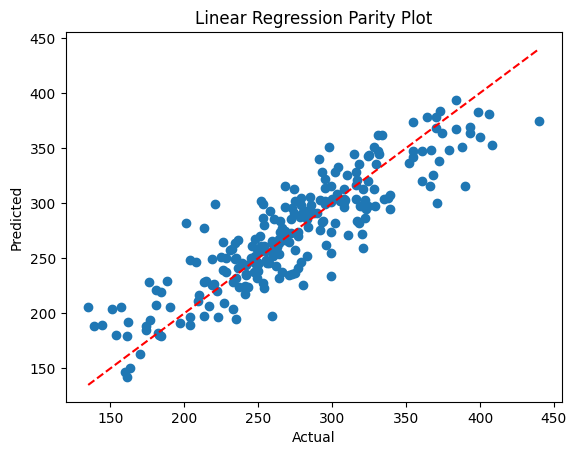

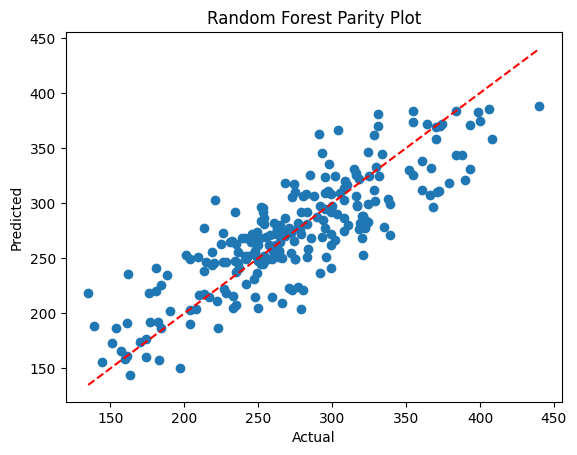

In [17]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, lr_pred, "Linear Regression Parity Plot")
parity_plot(y_test, rf_pred, "Random Forest Parity Plot")

In [18]:
# Get feature names after encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547
8,num__store_id,0.062056
6,cat__store_size_medium,0.058178
11,num__competition_density,0.053486
13,num__month,0.040473
4,cat__location_type_semi-urban,0.038886


The top 5 most important features include store size, promotion type, and competition density.
These factors significantly influence the number of items sold in a retail store.